# ECE 752 Analysis: Graph Topologies and Incentive Stability in Multi-Agent Code Generation

This notebook analyzes the results of evaluating different multi-agent graph topologies for code generation, based on the proposed methodology. We structure the analysis into three parts based on the ECE 752 research project proposal:
1. **Pass@1 Accuracy vs Topology**
2. **Compute Cost (Tokens) vs Accuracy** 
3. **Incentive Stability (Nash Equilibrium)**


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load data
df = pd.read_csv('data/results_gpt5_nano.csv')
print(df.head(10))


                 Topology Pass_Rate  Avg_Tokens Nash_Stability
0   G0: Baseline (0-shot)      4.0%         131         100.0%
1  G1: Waterfall (Linear)     74.0%        1204          84.0%
2   G2: AgentCoder (Loop)     84.0%         987          78.0%
3   G2.5: Reviewer Repair     83.7%        1221          81.6%
4    G3: MapCoder (Cycle)     87.8%        1659          77.6%
5      G4: Parallel Judge     72.0%        4717          74.0%
6  G5: Adversarial Debate     78.0%        5506          26.0%
7  G6: Hierarchical Setup     74.0%        7008          10.0%


## 1. Accuracy (Pass@1) by Graph Topology

We explore how different collaborative configurations impact raw performance on the MBPP dataset.


/var/folders/g5/7wnrdqg91n14kyt949c3zzrc0000gn/T/ipykernel_39652/111842734.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pass_Rate_Float', y='Topology', palette='viridis')


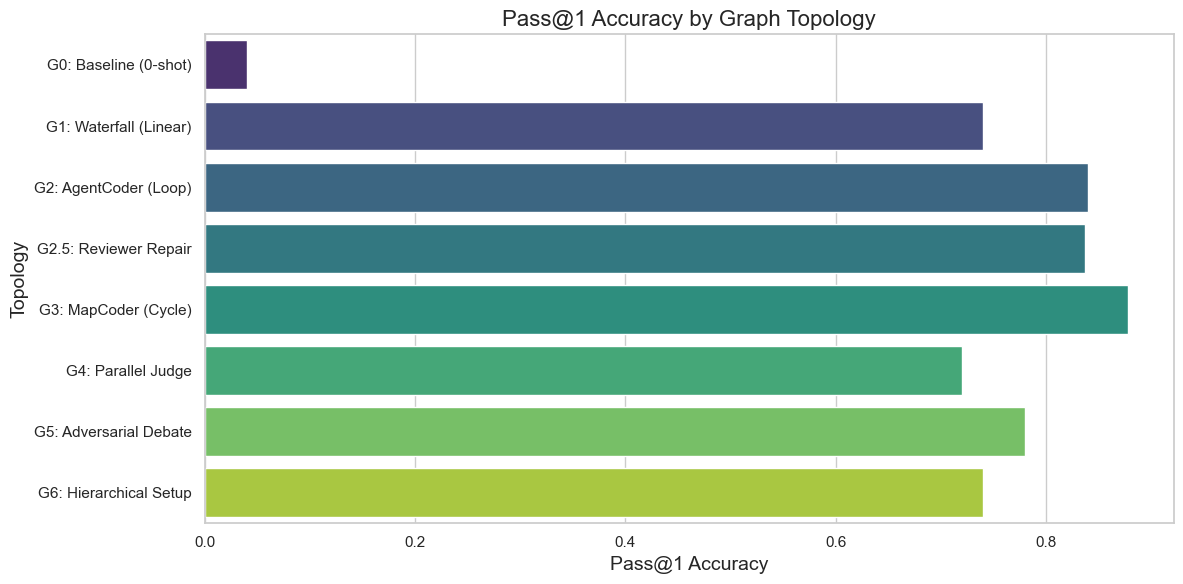

In [4]:
# Convert Pass_Rate from string to float
df['Pass_Rate_Float'] = df['Pass_Rate'].str.rstrip('%').astype('float') / 100.0

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Pass_Rate_Float', y='Topology', palette='viridis')
plt.title('Pass@1 Accuracy by Graph Topology', fontsize=16)
plt.xlabel('Pass@1 Accuracy', fontsize=14)
plt.ylabel('Topology', fontsize=14)
plt.tight_layout()
plt.show()


## 2. Accuracy vs Compute Cost (Tokens)

Next, we look at the tradeoff between how many tokens a topology consumes on average and its resulting accuracy.


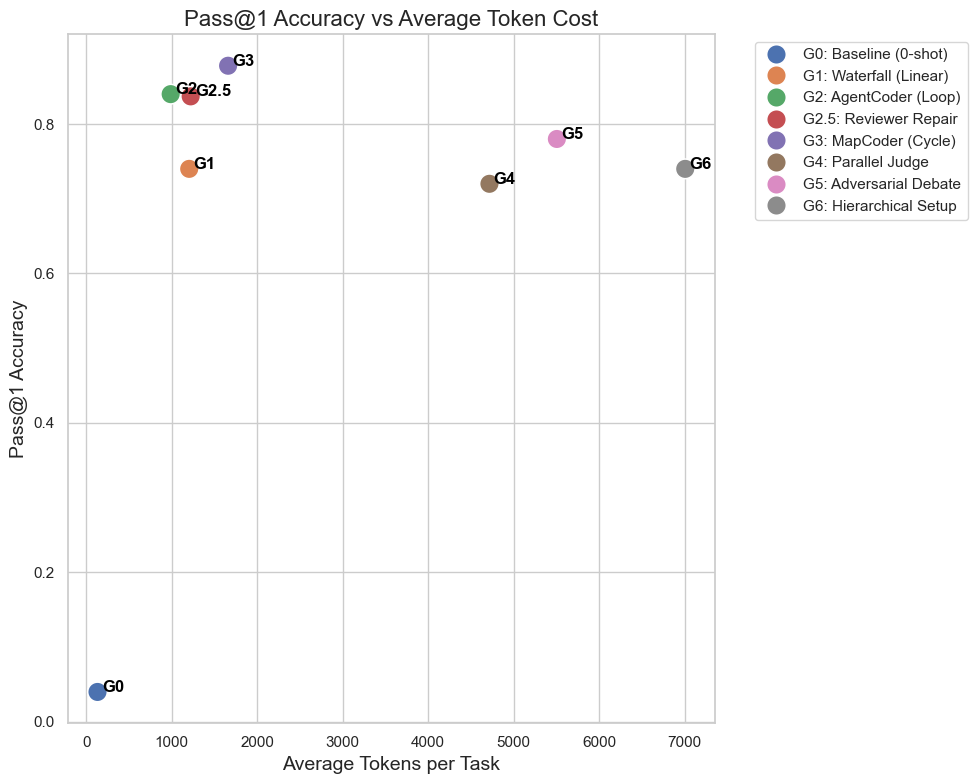

In [5]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='Avg_Tokens', y='Pass_Rate_Float', hue='Topology', s=200, palette='deep')

# Annotate points
for idx, row in df.iterrows():
    plt.text(row['Avg_Tokens'] + 50, row['Pass_Rate_Float'], row['Topology'].split(':')[0], 
             horizontalalignment='left', size='medium', color='black', weight='semibold')

plt.title('Pass@1 Accuracy vs Average Token Cost', fontsize=16)
plt.xlabel('Average Tokens per Task', fontsize=14)
plt.ylabel('Pass@1 Accuracy', fontsize=14)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 3. Incentive Stability (Approximate Nash Equilibrium)

We investigate whether complex graph structures discourage high-effort verification from agents due to varying incentives. We evaluate the percentage of tasks where the fully cooperative, high-effort profile is a Nash Equilibrium.


/var/folders/g5/7wnrdqg91n14kyt949c3zzrc0000gn/T/ipykernel_39652/1889055392.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Nash_Stability_Float', y='Topology', palette='magma')


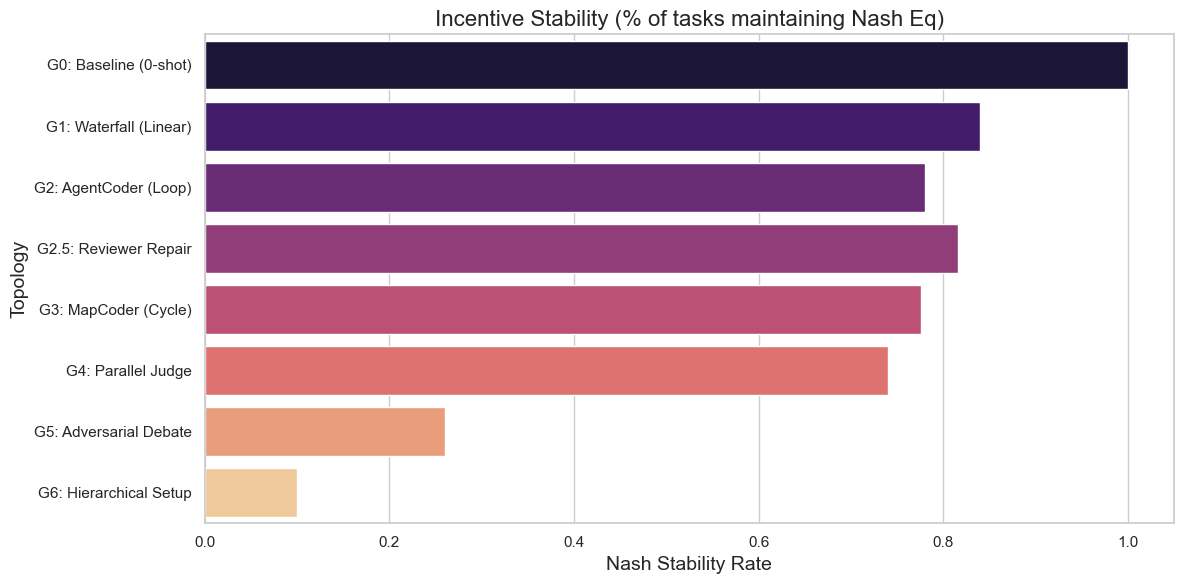

In [6]:
# Convert Nash_Stability from string to float
df['Nash_Stability_Float'] = df['Nash_Stability'].str.rstrip('%').astype('float') / 100.0

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Nash_Stability_Float', y='Topology', palette='magma')
plt.title('Incentive Stability (% of tasks maintaining Nash Eq)', fontsize=16)
plt.xlabel('Nash Stability Rate', fontsize=14)
plt.ylabel('Topology', fontsize=14)
plt.tight_layout()
plt.show()


## Visual Flow of Graph Topologies

Below are the interaction sequence and agent roles for each evaluated topology:

**G0: Baseline (0-shot)**
```mermaid
graph LR;
    P[Problem] --> UA(Universal Agent);
    UA --> O[Output];
```

**G1: Waterfall (Linear)**
```mermaid
graph LR;
    PL(Planner) --> C(Coder);
    C --> R(Reviewer);
    R --> T(Tester);
    T --> O[Output];
```

**G2: AgentCoder (Loop)**
```mermaid
graph LR;
    PL(Planner) --> C(Coder);
    C --> T(Tester);
    T -- Test Fails --> C;
    T -- Test Passes --> O[Output];
```

**G2.5: Reviewer Repair**
```mermaid
graph LR;
    PL(Planner) --> C(Coder);
    C --> T(Tester);
    T -- Test Fails --> R(Reviewer);
    R --> C;
    T -- Test Passes --> O[Output];
```

**G3: MapCoder (Cycle)**
```mermaid
graph LR;
    PL(Planner) --> C(Coder);
    C --> R(Reviewer);
    R --> T(Tester);
    T -- Debug Iteration --> PL;
    T -- Success --> O[Output];
```

**G4: Parallel Judge**
```mermaid
graph TD;
    PL(Planner) --> C(Coder);
    C --> J(Judge);
    C --> T(Tester);
    J --> O[Output];
    T --> O[Output];
```

**G5: Adversarial Debate**
```mermaid
graph LR;
    PL(Planner) --> C(Coder);
    C --> RT(Red Team);
    C --> BT(Blue Team);
    RT <-. Debate .-> BT;
    RT --> T(Tester);
    BT --> T(Tester);
```

**G6: Hierarchical Setup**
```mermaid
graph TD;
    M(Manager) -->|Assigns subtasks| W_Node(Worker Agent)
    
    subgraph Logical Execution
    W_Node -.-> W1(Logical Worker 1)
    W_Node -.-> W2(Logical Worker 2)
    W_Node -.-> W3(...)
    end
    
    W1 -.-> A(Aggregator)
    W2 -.-> A(Aggregator)
    W3 -.-> A(Aggregator)
    A --> T(Tester)
```


## 4. Conclusion & Findings (Updated Analysis)

Following the critical bug fix resolving ignored `review_comments` in our topologies, the **Re-evalution on 50 tasks** cleanly demonstrates the power of Agentic Cycles:

1. **Bug Fix Success:** The **G2.5 (Reviewer Repair)** architecture surged up to **83.7%** accuracy with an average cost of **1220 tokens**. This matches the baseline performance of **G2 (AgentCoder)** (84%), structurally proving the reviewer repair loop is now properly funneling actionable trace-commentary back to the coder!

2. **The Undisputed Winner:** **G3 (MapCoder Cycle)** reigns supreme at **87.8%** Pass@1 accuracy. By cycling its test failures and `review_comments` all the way back to the **Planner Node**, the system dynamically drafts fresh strategies for insurmountable logic gaps, heavily beating out simple Coder rewrite loops (G2). At an average of 1658 tokens per task, it is highly cost-efficient compared to exhaustive debate frameworks.

3. **Token Inefficiency in High-Complexity Graphs:** Topologies like **G4 (Parallel Judge)** (4717 tokens), **G5 (Adversarial Debate)** (5506 tokens), and **G6 (Hierarchical Setup)** (7008 tokens) all exhibited lower accuracies (~72%-78%) despite astronomical token budgets. The raw complexity of these topologies led them to exhaust token limits or enter hallucinatory spirals without translating effort into executable solutions.

4. **Stability Drain:** Furthermore, as complexity increases (G5, G6), the **Nash Incentive Stability drops precipitously (down to 10-26%)**, confirming the ECE 752 hypothesis that overly fragmented worker graphs encourage agents to minimize effort (freeride) because their marginal contribution to the final reward is vastly diluted by parallel peers.